### Reading ECCOv4r6 data 

Converting the binary files into netcdf 
- AHS

In [1]:
#Import packages
import earthaccess
import xarray as xr
import xmitgcm
import dask
import ecco_v4_py as ecco
import ecco_access as ea
import glob
from pathlib import Path
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

/oscar/home/asiddi48/ocean_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ## My earthdata login

# from netrc import netrc
# netrc_file = netrc()
# print(netrc_file.authenticators("urs.earthdata.nasa.gov"))

This code block gets changed slightly depending on the snap, mean or 2D variable being processed

In [10]:
def load_eccov5_year_by_index(
    year,
    geom,
    var_name=None,
    data_dir=None,
    output_dir=None,
):

    start_year = 1992
    end_year = 2024

    if year < start_year or year > end_year:
        raise ValueError(f"Year must be between {start_year} and {end_year}")

    # Directories
    if data_dir is None:
        # data_dir = f"/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/binary/{var_name}_mon_mean"
        data_dir = f"/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/binary/{var_name}_mon_snap"

    if output_dir is None:
        # output_dir = f"/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/{var_name}_mon_mean"
        output_dir = f"/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/{var_name}_mon_snap"

    data_dir = Path(data_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    all_files = sorted(data_dir.glob("*.data"))

    year_index = year - start_year
    start_idx = year_index * 12
    end_idx = start_idx + 12
    year_files = all_files[start_idx:end_idx]

    time_coord = pd.date_range(f"{year}-01-01", f"{year}-12-01", freq="MS")
    # time_coord = pd.date_range(f"{year}-01-01", f"{year}-12-01", freq="MS") + pd.Timedelta(days=14)

    arrays = []

    # --------------------------------------------------
    # Determine var_type + vertical dimension
    # --------------------------------------------------

    if var_name in ["ADVx_TH", "DFxE_TH"]:
        var_type = "w"      # west face → i_g
        nk = 50
        vertical_dim = "k"

    elif var_name in ["ADVy_TH", "DFyE_TH"]:
        var_type = "s"      # south face → j_g
        nk = 50
        vertical_dim = "k"

    elif var_name in ["ADVr_TH", "DFrE_TH", "DFrI_TH"]:
        var_type = "c"      # vertical handled manually
        nk = 50
        vertical_dim = "k_l"

    elif var_name in ["THETA"]:
        var_type = "c"
        nk = 50
        vertical_dim = "k"

    elif var_name in ["ETAN", "TFLUX", "oceQsw"]:
        var_type = "c"
        nk = 1
        vertical_dim = None

    else:
        raise ValueError(f"Unknown variable {var_name}")

    # --------------------------------------------------
    # Read each month
    # --------------------------------------------------

    for i, filepath in enumerate(year_files):

        array = ecco.read_llc_to_tiles(
            str(filepath.parent),
            filepath.name,
            llc=90,
            nk=nk,
            less_output=True,
        )

        # Convert tiles → DataArray
        ds = ecco.llc_tiles_to_xda(
            data_tiles=array,
            var_type=var_type,
            dim4="k" if nk > 1 else None,
            dim5=None,
        )

        ds = ds.rename(var_name)

        # --------------------------------------------------
        # Fix vertical staggering for ADVr/DFr*
        # --------------------------------------------------
        if vertical_dim == "k_l":
            ds = ds.rename({"k": "k_l"})

        # --------------------------------------------------
        # Attach geometry coordinates
        # --------------------------------------------------
        for dim in ds.dims:
            if dim in geom.coords:
                ds = ds.assign_coords({dim: geom[dim]})

        # Add time
        ds = ds.expand_dims("time")
        ds = ds.assign_coords(time=[time_coord[i]])

        arrays.append(ds)

    print(f"{var_name} year {year}: collected {len(arrays)} arrays")
    combined = xr.concat(arrays, dim="time")

    # out_file = output_dir / f"{var_name}_mon_mean_{year}.nc"
    out_file = output_dir / f"{var_name}_mon_snap_{year}.nc"
    print(f"Saving {out_file}")
    combined.to_netcdf(out_file)

    print(f"Saved {out_file}")

    return combined

In [11]:
grid = xr.open_dataset('/oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/GRID_GEOMETRY_ECCO_V4r5_native_llc0090.nc')

Play around with the vars to make sure the previous code block is adjusted before running for each var

In [15]:
%%time 
        
# var_names = ["ADVr_TH", "ADVy_TH", "ADVx_TH", "TFLUX", "oceQsw", "DFrI_TH", "DFyE_TH", "DFrE_TH", "DFxE_TH"]
# var_names = ["ETAN"]
var_names = ["THETA"]
for var in var_names:
    print(f"\n================ Processing {var} ================\n")
    for year in range(1992, 2025):
        load_eccov5_year_by_index(year, grid, var_name=var)



================ Processing THETA ================

THETA year 1992: collected 12 arrays
Saving /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1992.nc
Saved /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1992.nc
THETA year 1993: collected 12 arrays
Saving /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1993.nc
Saved /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1993.nc
THETA year 1994: collected 12 arrays
Saving /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1994.nc
Saved /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1994.nc
THETA year 1995: collected 12 arrays
Saving /oscar/data/deeps/private/chorvat/asiddi48/ECCO_analysis/ECCOv4r6/netcdf/THETA_mon_snap

### Verify

Check to see if the files are correctly written

In [16]:
ds_advx = xr.open_dataset('ECCOv4r6/netcdf/ADVx_TH_mon_mean/ADVx_TH_mon_mean_1992.nc')
ds_advx

<xarray.Dataset> Size: 253MB
Dimensions:  (time: 12, k: 50, tile: 13, j: 90, i_g: 90)
Coordinates:
  * time     (time) datetime64[ns] 96B 1992-01-15 1992-02-15 ... 1992-12-15
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B ...
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g      (i_g) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Data variables:
    ADVx_TH  (time, k, tile, j, i_g) float32 253MB ...

In [19]:
ds_theta_snap = xr.open_dataset('ECCOv4r6/netcdf/THETA_mon_snap/THETA_mon_snap_1992.nc')
ds_theta_snap

<xarray.Dataset> Size: 253MB
Dimensions:  (time: 12, k: 50, tile: 13, j: 90, i: 90)
Coordinates:
  * time     (time) datetime64[ns] 96B 1992-01-01 1992-02-01 ... 1992-12-01
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B ...
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Data variables:
    THETA    (time, k, tile, j, i) float32 253MB ...

In [14]:
ds_etan = xr.open_dataset('ECCOv4r6/netcdf/ETAN_mon_snap/ETAN_mon_snap_1992.nc')
ds_etan

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 12, tile: 13, j: 90, i: 90)
Coordinates:
  * time     (time) datetime64[ns] 96B 1992-01-01 1992-02-01 ... 1992-12-01
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Data variables:
    ETAN     (time, tile, j, i) float32 5MB ...

Some figures to check data

CPU times: user 2 μs, sys: 2 μs, total: 4 μs
Wall time: 5.96 μs


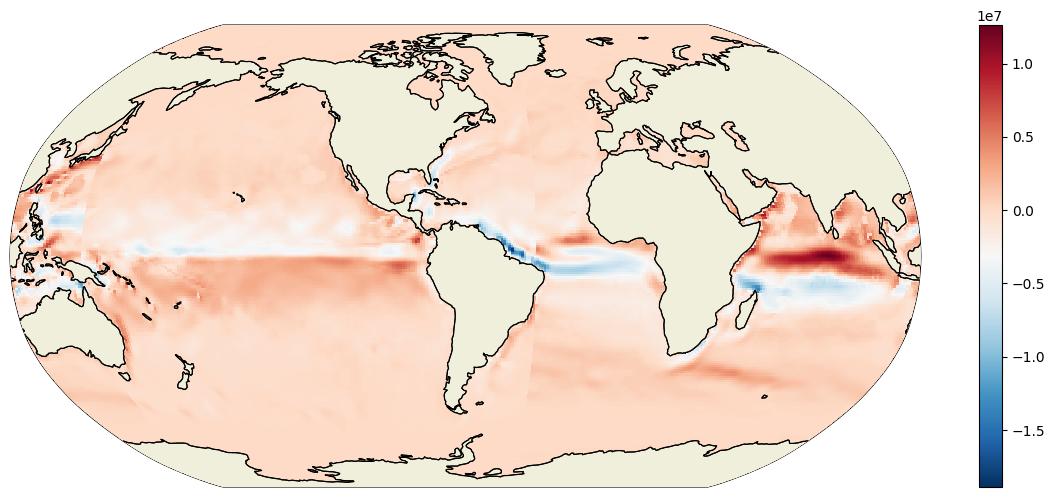

In [20]:
%time
    
plt.figure(figsize=(15,6));
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, ds_advx.ADVx_TH.sel(time='1992-05-15', k=1), show_colorbar=True, user_lon_0=-66);

CPU times: user 1e+03 ns, sys: 1e+03 ns, total: 2 μs
Wall time: 4.77 μs


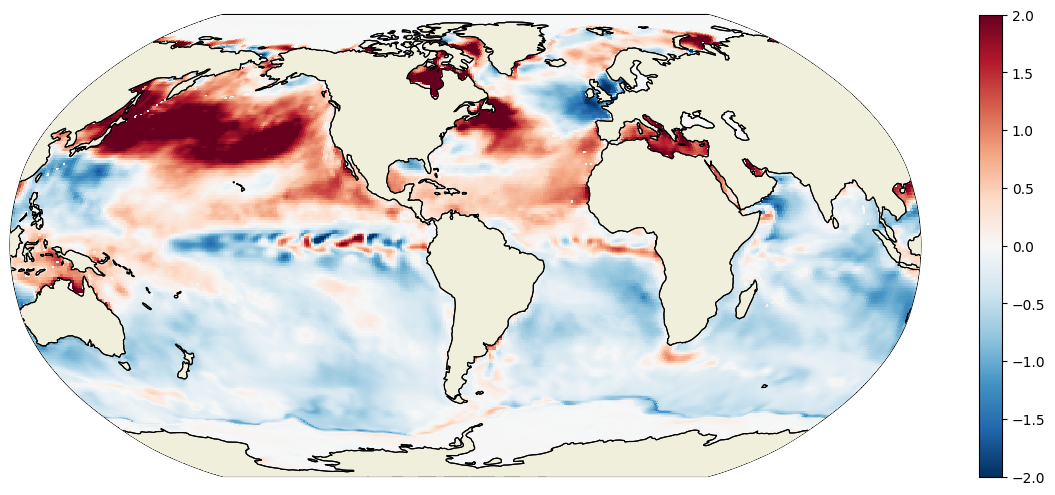

In [21]:
%time
    
plt.figure(figsize=(15,6));
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, (ds_theta_snap.THETA.sel(time='1992-08-01', k=0)- ds_theta_snap.THETA.sel(time='1992-07-01', k=1)), cmin=-2, cmax = 2, show_colorbar=True, user_lon_0=-66);

CPU times: user 1e+03 ns, sys: 2 μs, total: 3 μs
Wall time: 4.05 μs


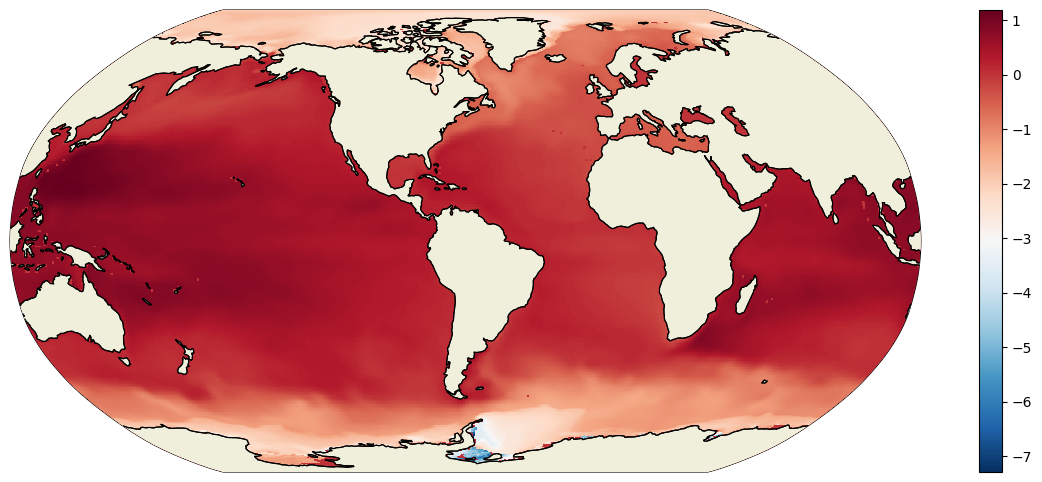

In [22]:
%time
    
plt.figure(figsize=(15,6));
ecco.plot_proj_to_latlon_grid(grid.XC, grid.YC, ds_etan.ETAN.sel(time='1992-05-01'), show_colorbar=True, user_lon_0=-66);